In [1]:
import json
from collections import Counter
from matplotlib import pyplot as plt

In [2]:
with open('1-raw/native_mcqs.json', 'r') as f:
    native_mcqs = json.load(f)

In [3]:
native_mcqs[0]

{'question_number': 1,
 'question': 'ہوا میں کونسی گیس ہوتی ہے؟',
 'options': {'A': 'نائٹروجن',
  'B': 'آکسیجن',
  'C': 'کاربن ڈائی آکسائیڈ',
  'D': 'ہائیڈروجن'},
 'correct_answer': 'A',
 'correct_index': 0,
 'subdomain': 'Everyday Science MCQs',
 'domain': 'STEM',
 'source': 'etest.com.pk',
 'level': '',
 'url': 'https://etest.com.pk/category/everyday-science-mcqs/',
 'language': 'ur',
 'std_domain': 'STEM',
 'std_subdomain': 'everyday_science'}

In [4]:
# remove elements where std_subdomain is english_language, sindhi_language
native_mcqs = [mcq for mcq in native_mcqs if mcq['std_subdomain'] != 'english_language']
native_mcqs = [mcq for mcq in native_mcqs if mcq['std_subdomain'] != 'sindhi_language']

In [5]:
# unique subdomains in native_mcqs
subdomains = set(mcq['std_subdomain'] for mcq in native_mcqs)
subdomains

{'clerical_services',
 'current_affairs',
 'electrical_engineering',
 'elementary_mathematics',
 'everyday_science',
 'federal_investigation_law',
 'general_knowledge',
 'hajj_management',
 'high_school_computer_science',
 'international_affairs',
 'islamic_studies',
 'pakistan_studies',
 'pedagogy',
 'professional_development',
 'professional_psychology',
 'psychometrics',
 'social_studies',
 'urdu_grammar',
 'urdu_language',
 'urdu_literature'}

In [6]:
subdomain_mapping = {
    'clerical_services': 'clerical services',
    'current_affairs': 'current and international affairs',
    'electrical_engineering': 'physics',
    'electrical engineering': 'physics',
    'elementary_mathematics': 'mathematics',
    'everyday_science': 'general science',
    'federal_investigation_law': 'federal investigation law',
    'general_knowledge': 'general knowledge',
    'hajj_management': 'hajj management',
    'high_school_computer_science': 'computer science',
    'international_affairs': 'current and international affairs',
    'islamic_studies': 'islamic studies',
    'pakistan_studies': 'pakistan studies',
    'pedagogy': 'education',
    'professional_development': 'professional development',
    'professional_psychology': 'psychology',
    'social_studies': 'pakistan studies',
    'urdu_grammar': 'urdu grammar',
    'urdu_language': 'urdu language',
    'urdu_literature': 'urdu literature',
}

mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the std_subdomain key in native_data with mapped subdomain
for mcq in native_mcqs:
    original_subdomain = mcq['std_subdomain']
    mapped_subdomain = subdomain_mapping.get(original_subdomain, original_subdomain)
    mcq['std_subdomain'] = mapped_subdomain

In [7]:
# unique subdomains in native_mcqs
subdomains = set(mcq['std_subdomain'] for mcq in native_mcqs)
subdomains

{'clerical services',
 'computer science',
 'current and international affairs',
 'education',
 'federal investigation law',
 'general knowledge',
 'general science',
 'hajj management',
 'islamic studies',
 'mathematics',
 'pakistan studies',
 'physics',
 'professional development',
 'psychology',
 'psychometrics',
 'urdu grammar',
 'urdu language',
 'urdu literature'}

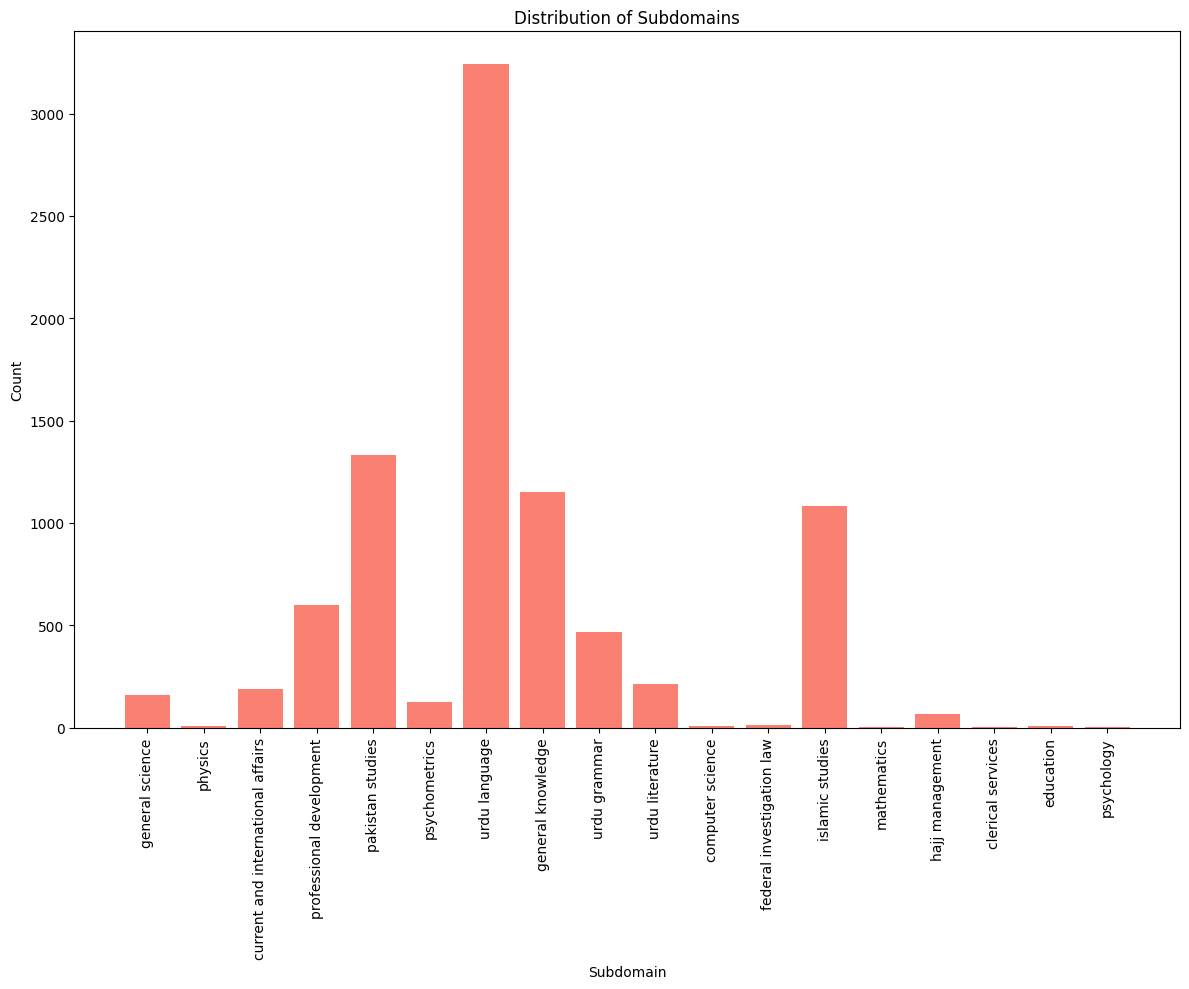

In [8]:
subdomains = [item['std_subdomain'] for item in native_mcqs]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [9]:
# replace url key with source_url key in native_mcqs
for mcq in native_mcqs:
    mcq['source_url'] = mcq.pop('url')

In [10]:
# Extract source name from source field. e.g., 'etest.com.pk -> etest, 
for mcq in native_mcqs:
    source = mcq['source']
    source_name = source.split('.')[0]  # get the first part before the dot
    mcq['source_name'] = source_name

In [11]:
# replace std_subdomain key with subdomain key in native_mcqs and remove std_domain, question number and language keys
for mcq in native_mcqs:
    mcq['subdomain'] = mcq.pop('std_subdomain')
    mcq["correct_option"] = mcq.pop("correct_answer")
    mcq.pop("std_domain")
    mcq.pop("language")
    mcq.pop("question_number")

In [12]:
# replace source_name key with source key in native_mcqs
for mcq in native_mcqs:
    mcq['source'] = mcq.pop('source_name')


In [13]:
native_mcqs[0]

{'question': 'ہوا میں کونسی گیس ہوتی ہے؟',
 'options': {'A': 'نائٹروجن',
  'B': 'آکسیجن',
  'C': 'کاربن ڈائی آکسائیڈ',
  'D': 'ہائیڈروجن'},
 'correct_index': 0,
 'subdomain': 'general science',
 'domain': 'STEM',
 'source': 'etest',
 'level': '',
 'source_url': 'https://etest.com.pk/category/everyday-science-mcqs/',
 'correct_option': 'A'}

In [14]:
with open('2-processed/native_mcqs.json', 'w', encoding='utf-8') as f:
    json.dump(native_mcqs, f, ensure_ascii=False, indent=4)